In [9]:
import boto3
from urllib.parse import urlparse
from pathlib import Path
import re
import pandas as pd
import numpy as np
import plotly.express as px
import os

# -------- CONFIG --------
# Path to the LOCAL inference CSV results
inference_folder = Path(r"C:\Users\amitg\OneDrive\Documents\Deep_Voice\HF_WAV_Manatee_Samples\Africa\ft_belize")

# S3 URI where the original WAV files are located
s3_wav_uri = "s3://deepvoice-user-uploads/biobbrady@gmail.com/dropbox/Cameroon_Ntem_River/"

glob_pattern = "Inference_results-2025-*.csv"
selected_class_name = "1"
threshold = 0.99

# Regex to parse the inference filename
fname_re = re.compile(
    r"""^Inference_results-
        (?P<inf_date>\d{4}-\d{2}-\d{2})_(?P<inf_time>\d{2}-\d{2}-\d{2})-
        .*?-
        (?P<rec_date>\d{8})_(?P<rec_time>\d{6})
        \.csv$""",
    re.VERBOSE
)

# ---------------- STEP 1: MAP WAV FILES TO SUBFOLDERS (VIA S3) ----------------
print(f"Scanning S3: {s3_wav_uri} ...")

def parse_s3_uri(uri):
    parsed = urlparse(uri, allow_fragments=False)
    return parsed.netloc, parsed.path.lstrip('/')

bucket_name, prefix = parse_s3_uri(s3_wav_uri)
s3 = boto3.client('s3')
paginator = s3.get_paginator('list_objects_v2')

wav_map = {} # Key: "20250513_173110", Value: "SubfolderName"

# We iterate through all objects under the prefix
page_iterator = paginator.paginate(Bucket=bucket_name, Prefix=prefix)

for page in page_iterator:
    if "Contents" not in page:
        continue
    
    for obj in page['Contents']:
        key = obj['Key']
        # We only care about .wav or .WAV files
        if not key.lower().endswith('.wav'):
            continue
            
        # Extract filename stem (e.g. "20250513_173110") from "path/to/20250513_173110.WAV"
        filename = os.path.basename(key)
        stem = os.path.splitext(filename)[0]
        
        # Extract the subfolder immediately containing the file
        # Key: .../Cameroon_Ntem_River/SiteA/2025...wav
        # We want: SiteA
        
        # 1. Remove the filename
        parent_path = os.path.dirname(key)
        
        # 2. Get the last part of the directory path
        # If the file is directly in the prefix, this might be the prefix end.
        # We check if the parent_path is strictly longer than the prefix to avoid empty names
        if len(parent_path) > len(prefix.rstrip('/')):
            subfolder_name = os.path.basename(parent_path)
        else:
            subfolder_name = "Root" # File is directly in the base folder

        wav_map[stem] = subfolder_name

print(f"Mapped {len(wav_map)} original audio files from S3.")


# ---------------- STEP 2: PARSE INFERENCE FILES (LOCAL) ----------------

def parse_filename_times(name: str):
    m = fname_re.match(name)
    if not m:
        return None, None, None
    inf_date = m.group("inf_date")
    inf_time = m.group("inf_time")
    rec_date = m.group("rec_date")
    rec_time = m.group("rec_time")
    
    inference_dt = pd.to_datetime(f"{inf_date} {inf_time.replace('-',':')}")
    recording_dt = pd.to_datetime(f"{rec_date}_{rec_time}", format="%Y%m%d_%H%M%S")
    
    # Return the string key to look up in our wav_map
    file_key = f"{rec_date}_{rec_time}"
    
    return inference_dt, recording_dt, file_key

def find_selected_class_column(columns, key):
    matches = [c for c in columns if key in c]
    if not matches:
        raise ValueError(f"Couldn't find a column containing '{key}' in {list(columns)}")
    return matches[0]

frames = []
files_processed = 0

for f in sorted(inference_folder.glob(glob_pattern)):
    inf_dt, rec_dt, file_key = parse_filename_times(f.name)
    
    if rec_dt is None:
        continue

    # Look up the subfolder from our S3 map
    # If the exact time key isn't found, we label it 'Unknown'
    subfolder = wav_map.get(file_key, "Unknown_Subfolder")
    
    df = pd.read_csv(f)
    sel_col = find_selected_class_column(df.columns, selected_class_name)

    # Build timestamps
    if "begin_time" in df.columns:
        ts = rec_dt + pd.to_timedelta(df["begin_time"], unit="s")
    else:
        seq_len = df["call_length"].iloc[0] if "call_length" in df.columns else 0.2
        ts = rec_dt + pd.to_timedelta(np.arange(len(df)) * seq_len, unit="s")

    out = df.copy()
    out["timestamp"] = ts
    out["file"] = f.name
    out["subfolder"] = subfolder 
    out["_selected_prob"] = out[sel_col]
    frames.append(out)
    files_processed += 1

if not frames:
    raise RuntimeError("No files matched or all skipped.")

print(f"Processed {files_processed} inference files.")
df_all = pd.concat(frames, ignore_index=True)

# ---------------- STEP 3: AGGREGATE STATS ----------------

df_all["predicted_call"] = df_all["_selected_prob"] > threshold
df_all["prev_call"] = df_all["predicted_call"].shift(fill_value=False)
df_all["call_event"] = df_all["predicted_call"] & (~df_all["prev_call"])

# --- STATS: Average detected per recording in each subfolder ---
per_file_stats = df_all.groupby(["subfolder", "file"])["call_event"].sum().reset_index()

subfolder_summary = per_file_stats.groupby("subfolder")["call_event"].agg(
    files_count="count",
    total_calls="sum",
    avg_calls_per_file="mean"
).sort_values("avg_calls_per_file", ascending=False).reset_index()

print("\n--- Summary by Subfolder ---")
print(subfolder_summary)


Scanning S3: s3://deepvoice-user-uploads/biobbrady@gmail.com/dropbox/Cameroon_Ntem_River/ ...
Mapped 4759 original audio files from S3.
Processed 11211 inference files.

--- Summary by Subfolder ---
                subfolder  files_count  total_calls  avg_calls_per_file
0    1_Ipono2_Recorder A1            1            3            3.000000
1    1_Poste2_Recorder A3         6478         2977            0.459555
2  2_Mabiogo2_Recorder A2            7            1            0.142857
3    2_Poste2_Recorder A1         4719          162            0.034329
4  1_Mabiogo2_Recorder A2            6            0            0.000000


C:\Users\amitg\AppData\Local\Temp\ipykernel_45404\1181411487.py:10: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.

C:\Users\amitg\AppData\Local\Temp\ipykernel_45404\1181411487.py:20: FutureWarning:

'T' is deprecated and will be removed in a future version, please use 'min' instead.



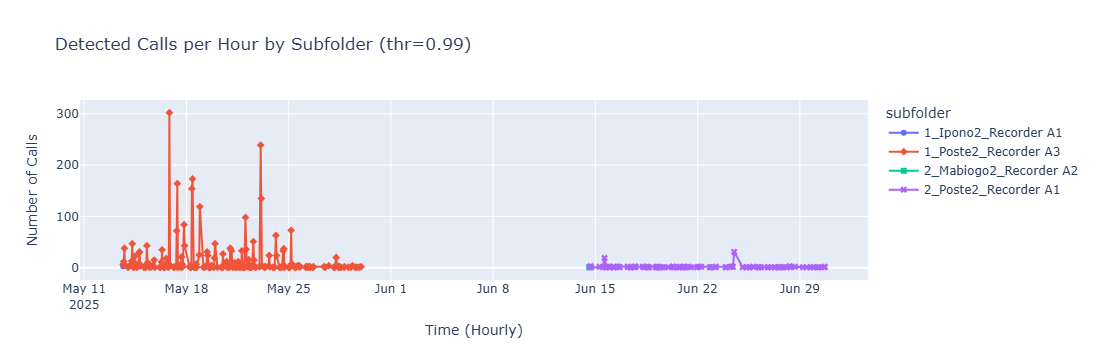

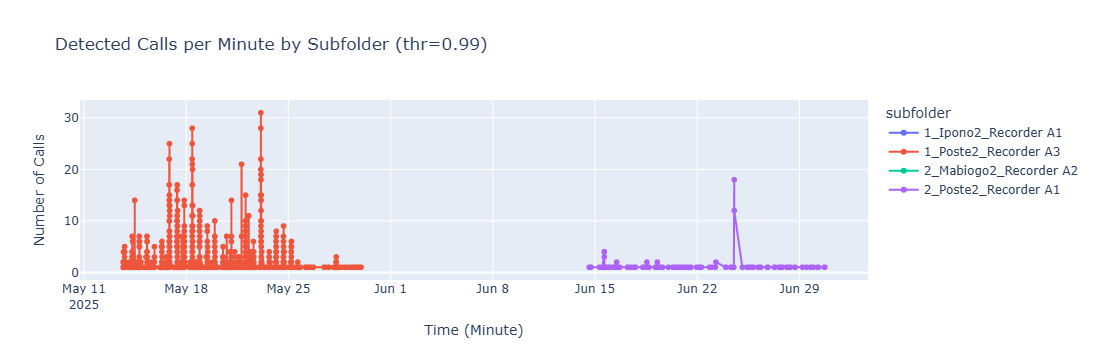

In [10]:

# ---------------- STEP 4: PLOTS ----------------

events_df = df_all[df_all["call_event"]].copy()

if not events_df.empty:
    # Hourly Data
    hourly_df = (
        events_df
        .set_index("timestamp")
        .groupby([pd.Grouper(freq="H"), "subfolder"])["call_event"]
        .sum()
        .reset_index()
        .rename(columns={"call_event": "calls"})
    )

    # Minute Data
    minute_df = (
        events_df
        .set_index("timestamp")
        .groupby([pd.Grouper(freq="T"), "subfolder"])["call_event"]
        .sum()
        .reset_index()
        .rename(columns={"call_event": "calls"})
    )

    fig_h = px.line(
        hourly_df,
        x="timestamp", 
        y="calls", 
        color="subfolder", 
        title=f"Detected Calls per Hour by Subfolder (thr={threshold})",
        labels={"timestamp": "Time (Hourly)", "calls": "Number of Calls"},
        symbol="subfolder"
    )
    fig_h.update_traces(mode="markers+lines", hovertemplate="<b>%{fullData.name}</b><br>Time: %{x}<br>Calls: %{y}")
    fig_h.show()

    fig_m = px.line(
        minute_df,
        x="timestamp", 
        y="calls", 
        color="subfolder", 
        title=f"Detected Calls per Minute by Subfolder (thr={threshold})",
        labels={"timestamp": "Time (Minute)", "calls": "Number of Calls"}
    )
    fig_m.update_traces(mode="markers+lines", hovertemplate="<b>%{fullData.name}</b><br>Time: %{x}<br>Calls: %{y}")
    fig_m.show()

else:
    print("No events detected above threshold. Cannot plot.")

C:\Users\amitg\AppData\Local\Temp\ipykernel_45404\2041988291.py:78: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  minute_counts = events_series.resample("T").sum().fillna(0)
C:\Users\amitg\AppData\Local\Temp\ipykernel_45404\2041988291.py:79: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_counts = events_series.resample("H").sum().fillna(0)


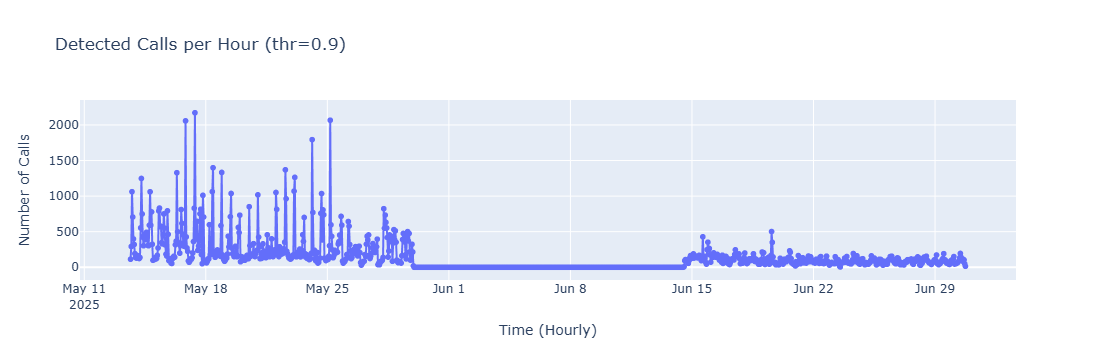

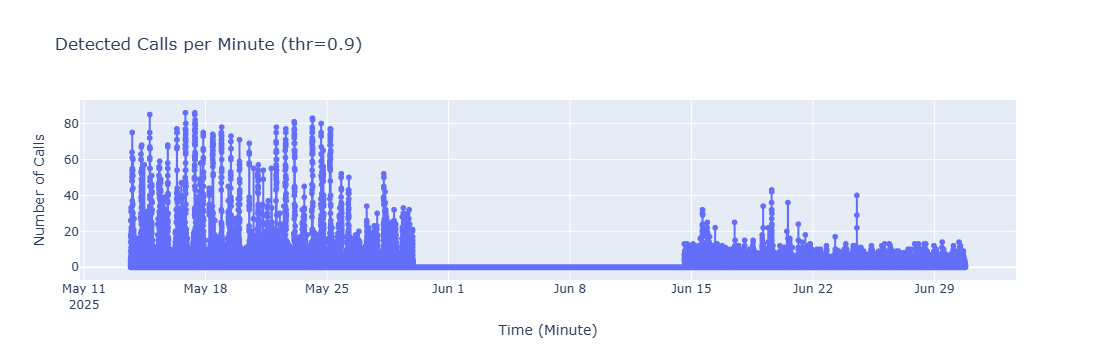